# Library

In [98]:
# 기본 라이브러리
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 머신러닝 관련 라이브러리
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# Load the dataset

In [99]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lavanyashukla01/particle-identification")

print("Path to dataset files:", path)

Path to dataset files: /Users/Jongseok/.cache/kagglehub/datasets/lavanyashukla01/particle-identification/versions/1


In [100]:
import pandas as pd
import os

# 데이터 저장 경로 (사용자 환경에 따라 다를 수 있음)
base_path = "/Users/Jongseok/.cache/kagglehub/datasets/lavanyashukla01/particle-identification/versions/1"

print(f"데이터 폴더 확인: {base_path}")

# 1. 폴더 안에 있는 파일 목록 확인
if os.path.exists(base_path):
    file_list = os.listdir(base_path)
    print("파일 목록:", file_list)
    
    # 2. CSV 파일 찾기 (보통 training.csv 또는 data.csv)
    csv_files = [f for f in file_list if f.endswith('.csv')]
    
    if len(csv_files) > 0:
        full_path1 = os.path.join(base_path, csv_files[0])
        full_path2 = os.path.join(base_path, csv_files[1])

        train_df = pd.read_csv(full_path1)
        test_df = pd.read_csv(full_path2)
        
        print(f"Load complete: {train_df.shape}")
        print(f"Load complete: {test_df.shape}")
            
    else:
        print("❌ 폴더는 찾았지만, .csv 파일이 보이지 않습니다. 압축(.zip)이 덜 풀렸는지 확인이 필요합니다.")
else:
    print(f"❌ 경로를 찾을 수 없습니다: {base_path}")

데이터 폴더 확인: /Users/Jongseok/.cache/kagglehub/datasets/lavanyashukla01/particle-identification/versions/1
파일 목록: ['training.csv', 'test.csv']
Load complete: (1200000, 50)
Load complete: (1200000, 50)


# Data Preprocessing

## Data Inspection

In [101]:
df = train_df.copy()
# 데이터프레임 정보 확인 (간략하게)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 50 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   TrackP                           1200000 non-null  float64
 1   TrackNDoFSubdetector2            1200000 non-null  float64
 2   BremDLLbeElectron                1200000 non-null  float64
 3   MuonLooseFlag                    1200000 non-null  float64
 4   FlagSpd                          1200000 non-null  float64
 5   SpdE                             1200000 non-null  float64
 6   EcalDLLbeElectron                1200000 non-null  float64
 7   DLLmuon                          1200000 non-null  float64
 8   RICHpFlagElectron                1200000 non-null  float64
 9   EcalDLLbeMuon                    1200000 non-null  float64
 10  TrackQualitySubdetector2         1200000 non-null  float64
 11  FlagPrs                          1200000 non-null 

In [102]:
df.head()

,TrackP,TrackNDoFSubdetector2,BremDLLbeElectron,MuonLooseFlag,FlagSpd,SpdE,EcalDLLbeElectron,DLLmuon,RICHpFlagElectron,EcalDLLbeMuon,...,TrackNDoF,RICHpFlagMuon,RICH_DLLbeKaon,RICH_DLLbeElectron,HcalE,MuonFlag,FlagMuon,PrsE,RICH_DLLbeMuon,RICH_DLLbeProton
0,74791.156263,15.0,0.232275,1.0,1.0,3.2,-2.505719,6.604153,1.0,1.929960,...,28.0,1.0,-7.213300,-0.280200,5586.589846,1.0,1.0,10.422315,-2.081143e-07,-24.824400
1,2738.489989,15.0,-0.357748,0.0,1.0,3.2,1.864351,0.263651,1.0,-2.061959,...,32.0,1.0,-0.324317,1.707283,-0.000007,0.0,1.0,43.334935,2.771583e+00,-0.648017
2,2161.409908,17.0,-999.000000,0.0,0.0,-999.0,-999.000000,-999.000000,0.0,-999.000000,...,27.0,0.0,-999.000000,-999.000000,-999.000000,0.0,0.0,-999.000000,-9.990000e+02,-999.000000
3,15277.730490,20.0,-0.638984,0.0,1.0,3.2,-2.533918,-8.724949,1.0,-3.253981,...,36.0,1.0,-35.202221,-14.742319,4482.803707,0.0,1.0,2.194175,-3.070819e+00,-29.291519
4,7563.700195,19.0,-0.638962,0.0,1.0,3.2,-2.087146,-7.060422,1.0,-0.995816,...,33.0,1.0,25.084287,-10.272412,5107.554680,0.0,1.0,0.000015,-5.373712e+00,23.653087


- Head()를 통해 데이터 확인 후, -999와 같은 이상치 확인 

    - 이는 보통 NaN값 대신 채워지는 값으로, 이상치 처리 필요
    - 이를 그대로 두가 정규화 할 경우, 분포가 심각하게 망가짐

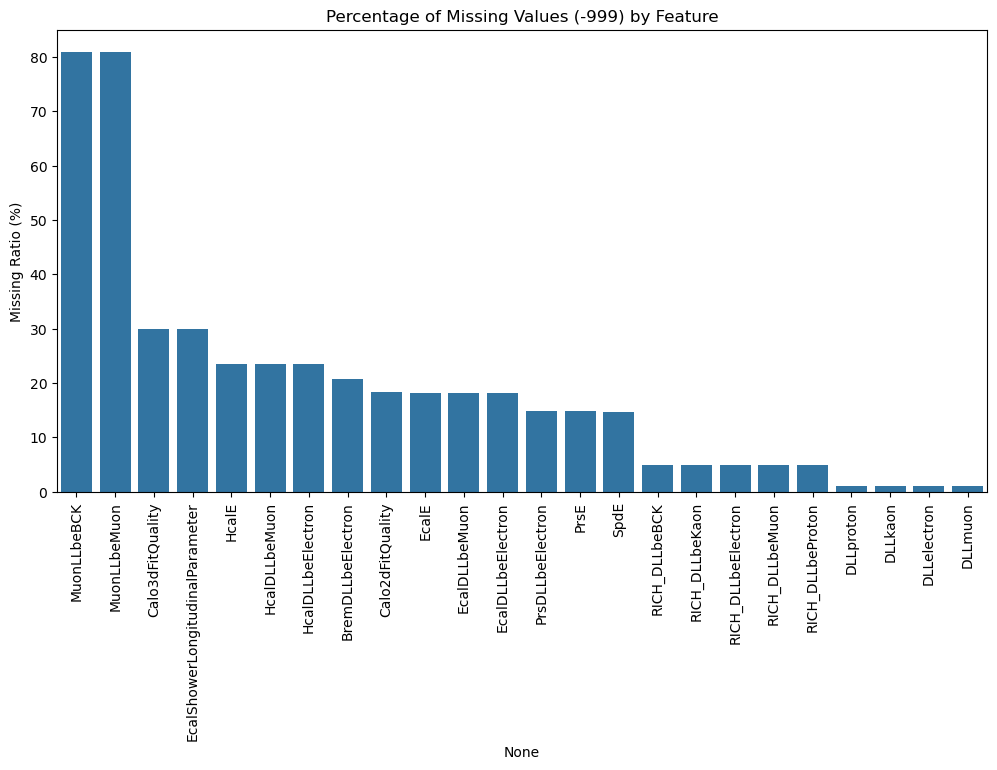

상위 결측 컬럼:
 MuonLLbeBCK                        80.937750
MuonLLbeMuon                       80.937750
Calo3dFitQuality                   29.932750
EcalShowerLongitudinalParameter    29.932750
HcalE                              23.498833
HcalDLLbeMuon                      23.498833
HcalDLLbeElectron                  23.498833
BremDLLbeElectron                  20.796750
Calo2dFitQuality                   18.289417
EcalE                              18.238083
dtype: float64


In [103]:
df_nan = df.replace(-999, np.nan)

# 결측치 비율 계산
missing_ratio = df_nan.isnull().sum() / len(df_nan) * 100
missing_ratio = missing_ratio[missing_ratio > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_ratio.index, y=missing_ratio.values)
plt.xticks(rotation=90)
plt.title('Percentage of Missing Values (-999) by Feature')
plt.ylabel('Missing Ratio (%)')
plt.show()

# 상위 결측 컬럼 출력
print("상위 결측 컬럼:\n", missing_ratio.head(10))

우선 결측치를 제거해놨지만, 추후 복원해야 할 듯
1. 큰 의미가 없는 columm의 값은 중앙값 혹은 평균으로 대체

In [104]:
# 결측치 제외 데이터프레임
df_clean = df_nan.dropna()
print(f"결측치 제거 후 데이터 크기: {df_clean.shape}")

# 기존 데이터프레임 대비 결측치 제거 후 데이터프레임 크기 비교
print(f"기존 데이터프레임 크기: {df.shape}")
print(f"결측치 제거 후 데이터프레임 크기: {df_clean.shape}")
# 비율 계산
print(f"결측치 제거 비율: {(1 - df_clean.shape[0] / df.shape[0]) * 100:.2f}%")

결측치 제거 후 데이터 크기: (125426, 50)
기존 데이터프레임 크기: (1200000, 50)
결측치 제거 후 데이터프레임 크기: (125426, 50)
결측치 제거 비율: 89.55%


In [105]:
df.columns

Index(['TrackP', 'TrackNDoFSubdetector2', 'BremDLLbeElectron', 'MuonLooseFlag',
       'FlagSpd', 'SpdE', 'EcalDLLbeElectron', 'DLLmuon', 'RICHpFlagElectron',
       'EcalDLLbeMuon', 'TrackQualitySubdetector2', 'FlagPrs', 'DLLelectron',
       'DLLkaon', 'EcalE', 'TrackQualityPerNDoF', 'DLLproton',
       'PrsDLLbeElectron', 'FlagRICH1', 'MuonLLbeBCK', 'FlagHcal',
       'EcalShowerLongitudinalParameter', 'Calo2dFitQuality', 'TrackPt',
       'TrackDistanceToZ', 'RICHpFlagPion', 'HcalDLLbeElectron',
       'Calo3dFitQuality', 'FlagEcal', 'MuonLLbeMuon', 'TrackNDoFSubdetector1',
       'RICHpFlagProton', 'RICHpFlagKaon', 'GhostProbability',
       'TrackQualitySubdetector1', 'Label', 'RICH_DLLbeBCK', 'FlagRICH2',
       'FlagBrem', 'HcalDLLbeMuon', 'TrackNDoF', 'RICHpFlagMuon',
       'RICH_DLLbeKaon', 'RICH_DLLbeElectron', 'HcalE', 'MuonFlag', 'FlagMuon',
       'PrsE', 'RICH_DLLbeMuon', 'RICH_DLLbeProton'],
      dtype='object')

In [106]:
# 중복 행 개수 확인
df.duplicated().sum()

np.int64(0)

In [107]:
df['Label'].unique()

array(['Muon', 'Ghost', 'Pion', 'Proton', 'Kaon', 'Electron'],
      dtype=object)

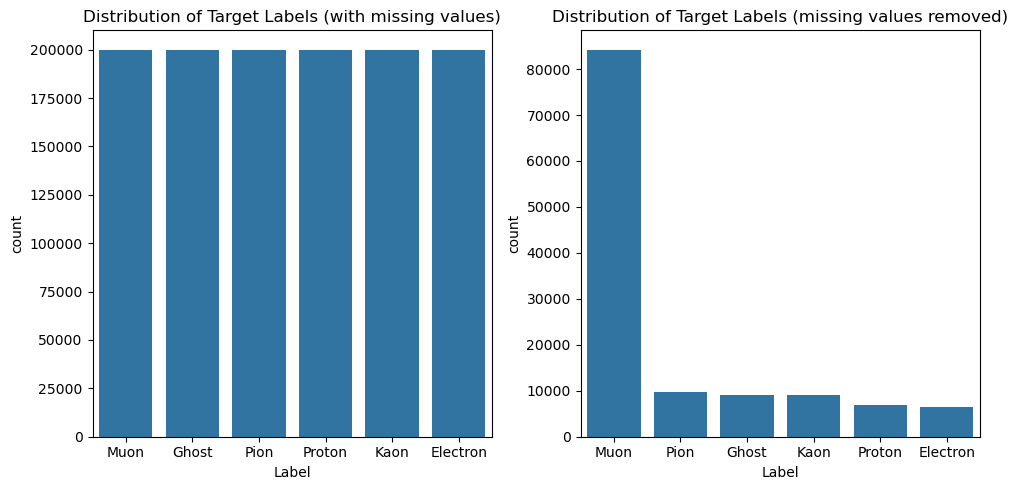

원본 데이터프레임 라벨 분포 비율:
Label
Muon        0.166667
Ghost       0.166667
Pion        0.166667
Proton      0.166667
Kaon        0.166667
Electron    0.166667
Name: proportion, dtype: float64

결측치 제거 후 데이터프레임 라벨 분포 비율:
Label
Muon        0.671456
Pion        0.077201
Ghost       0.072385
Kaon        0.072250
Proton      0.054431
Electron    0.052278
Name: proportion, dtype: float64


In [108]:
# 라벨 분포 시각화 (결측치 포함 vs 결측치 제거 후)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='Label', data=df)
plt.title('Distribution of Target Labels (with missing values)')
plt.subplot(1, 2, 2)
sns.countplot(x='Label', data=df_clean, order=df_clean['Label'].value_counts().index)
plt.title('Distribution of Target Labels (missing values removed)')
plt.tight_layout()
plt.show()
# 수치로 확인
print("원본 데이터프레임 라벨 분포 비율:")
print(df['Label'].value_counts(normalize=True))
print("\n결측치 제거 후 데이터프레임 라벨 분포 비율:")
print(df_clean['Label'].value_counts(normalize=True))

결측치 제거 후 라벨 분포가 크게 달라짐 

-> 불균형이 심하므로, Accuracy 대신 F1-score와 ROC-AUC 고려해야함

In [109]:
df_clean.describe()

,TrackP,TrackNDoFSubdetector2,BremDLLbeElectron,MuonLooseFlag,FlagSpd,SpdE,EcalDLLbeElectron,DLLmuon,RICHpFlagElectron,EcalDLLbeMuon,...,TrackNDoF,RICHpFlagMuon,RICH_DLLbeKaon,RICH_DLLbeElectron,HcalE,MuonFlag,FlagMuon,PrsE,RICH_DLLbeMuon,RICH_DLLbeProton
count,1.254260e+05,125426.000000,125426.000000,125426.000000,125426.000000,125426.000000,125426.000000,125426.000000,125426.000000,125426.000000,...,125426.000000,125426.000000,125426.000000,125426.000000,125426.000000,125426.000000,125426.000000,125426.000000,125426.000000,125426.000000
mean,1.598393e+04,15.455368,-0.036375,0.951438,0.961826,2.695530,-1.557880,3.465071,0.979247,0.182176,...,31.314265,0.973514,-18.637970,-4.756744,3278.247922,0.810566,0.968898,6.744167,2.161463,-18.663690
std,1.985168e+04,3.149270,0.964978,0.214952,0.191617,1.166115,1.687686,6.253546,0.142558,1.385802,...,4.437249,0.160575,30.196643,17.338427,4917.143087,0.391855,0.173594,15.529705,13.383486,29.626285
min,2.452720e+03,1.000000,-1.569851,0.000000,0.000000,0.000000,-3.283672,-13.058669,0.000000,-4.990883,...,8.000000,0.000000,-207.916911,-149.427994,-0.000035,0.000000,0.000000,-0.000037,-112.532100,-197.593884
25%,5.317515e+03,15.000000,-0.591407,1.000000,1.000000,3.200000,-2.723430,-1.404648,1.000000,-0.243356,...,29.000000,1.000000,-34.988922,-10.757260,1498.002211,1.000000,1.000000,1.919889,-1.916168,-35.625628
50%,9.157095e+03,16.000000,-0.461393,1.000000,1.000000,3.200000,-2.251541,4.916325,1.000000,0.494741,...,32.000000,1.000000,-11.942744,-2.216453,2200.135491,1.000000,1.000000,2.468447,0.553145,-12.616803
75%,1.919842e+04,17.000000,0.018125,1.000000,1.000000,3.200000,-0.881458,8.327690,1.000000,1.111233,...,34.000000,1.000000,2.745124,1.481980,3440.979497,1.000000,1.000000,3.839805,5.140548,3.071704
max,1.021948e+06,27.000000,4.791509,1.000000,1.000000,3.200000,4.341281,14.710791,1.000000,2.153012,...,48.000000,1.000000,109.943214,161.419701,241448.671890,1.000000,1.000000,280.580010,142.833498,103.802303


In [110]:
# 결측치 확인
print(df.isnull().sum())

TrackP                             0
TrackNDoFSubdetector2              0
BremDLLbeElectron                  0
MuonLooseFlag                      0
FlagSpd                            0
SpdE                               0
EcalDLLbeElectron                  0
DLLmuon                            0
RICHpFlagElectron                  0
EcalDLLbeMuon                      0
TrackQualitySubdetector2           0
FlagPrs                            0
DLLelectron                        0
DLLkaon                            0
EcalE                              0
TrackQualityPerNDoF                0
DLLproton                          0
PrsDLLbeElectron                   0
FlagRICH1                          0
MuonLLbeBCK                        0
FlagHcal                           0
EcalShowerLongitudinalParameter    0
Calo2dFitQuality                   0
TrackPt                            0
TrackDistanceToZ                   0
RICHpFlagPion                      0
HcalDLLbeElectron                  0
C

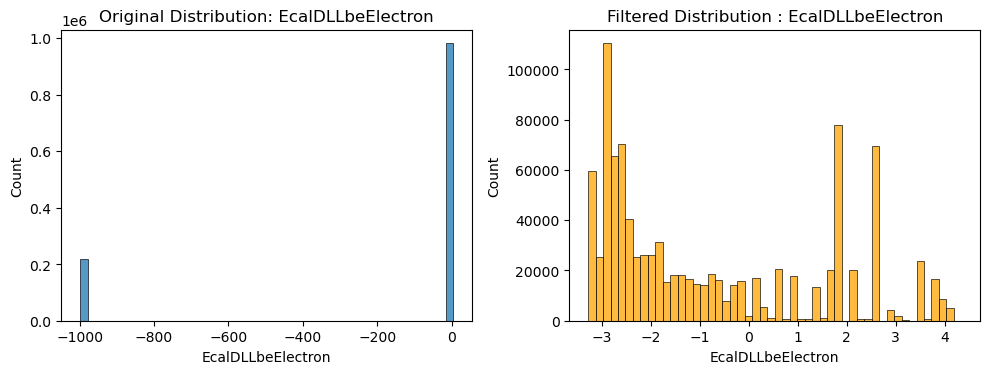

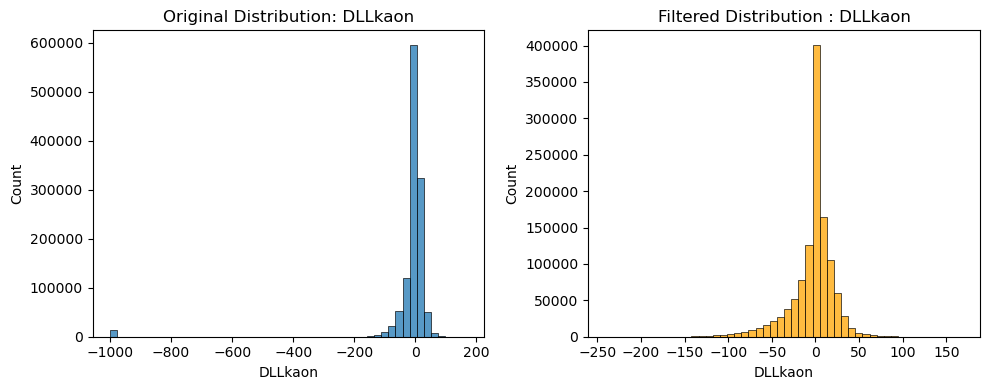

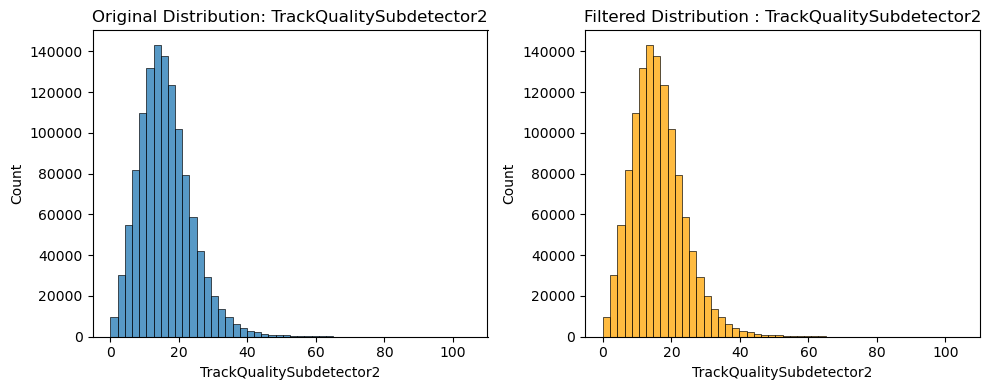

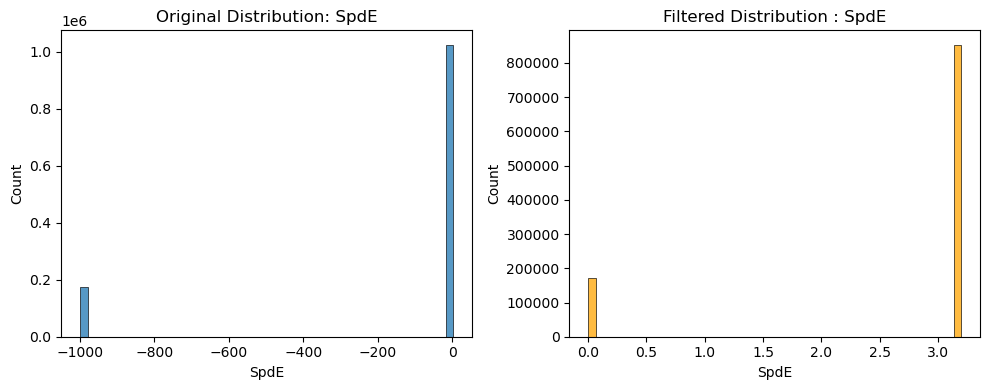

In [111]:
# 결측치 제거 전 후 특정 피처 분포 비교
feature_name = 'EcalDLLbeElectron', 'DLLkaon', 'TrackQualitySubdetector2', 'SpdE'

for feature_name in feature_name:

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # 원본 데이터
    sns.histplot(df[feature_name], bins=50, ax=axes[0])
    axes[0].set_title(f'Original Distribution: {feature_name}')

    # 결측치 제외 데이터
    sns.histplot(df_nan[feature_name].dropna(), bins=50, ax=axes[1], color='orange')
    axes[1].set_title(f'Filtered Distribution : {feature_name}')

    plt.tight_layout()

plt.show()

## Data Preprocessing

### Imputation

missing value를 처리할 때, 기존 데이터의 약 90%가 날아갔으므로, 이를 적절한 값으로 대치할 필요가 있음.

Methodology
1. Flagging + Mean Imputation

In [112]:

# [Step 1] 결측치 처리 (Flagging + Mean Imputation) 확정 적용
def impute_physics_data_final(df, missing_val=-999.0):
    df_imputed = df.copy()
    imputed_cols = []
    
    # 수치형 컬럼만 선택 (Label 제외)
    numeric_cols = df_imputed.select_dtypes(include=[np.number]).columns
    
    for col in numeric_cols:
        # 결측치가 하나라도 있는 경우에만 처리
        if (df_imputed[col] == missing_val).any():
            # 1. 유효 데이터의 평균 계산
            valid_mask = df_imputed[col] != missing_val
            mean_val = df_imputed.loc[valid_mask, col].mean()
            
            # 2. Flag 컬럼 생성 (결측=1, 정상=0)
            # 물리적 의미: "이 데이터는 원래 신호가 없었다"는 것을 모델에 명시
            df_imputed[f"{col}_flag"] = (~valid_mask).astype(int)
            
            # 3. 원래 컬럼의 결측치를 평균으로 대체
            df_imputed.loc[~valid_mask, col] = mean_val
            
            imputed_cols.append(col)
            
    return df_imputed, imputed_cols

# 함수 적용
df_final, imputed_cols = impute_physics_data_final(df)

print(f"Imputation 완료: {len(imputed_cols)}개의 컬럼 처리됨.")
print("데이터 크기(Shape):", df_final.shape)
print("Imputed Data Shape:", df_final.shape)
df_final.head()

Imputation 완료: 24개의 컬럼 처리됨.
데이터 크기(Shape): (1200000, 74)
Imputed Data Shape: (1200000, 74)


,TrackP,TrackNDoFSubdetector2,BremDLLbeElectron,MuonLooseFlag,FlagSpd,SpdE,EcalDLLbeElectron,DLLmuon,RICHpFlagElectron,EcalDLLbeMuon,...,Calo3dFitQuality_flag,MuonLLbeMuon_flag,RICH_DLLbeBCK_flag,HcalDLLbeMuon_flag,RICH_DLLbeKaon_flag,RICH_DLLbeElectron_flag,HcalE_flag,PrsE_flag,RICH_DLLbeMuon_flag,RICH_DLLbeProton_flag
0,74791.156263,15.0,0.232275,1.0,1.0,3.200000,-2.505719,6.604153,1.0,1.929960,...,1,0,0,0,0,0,0,0,0,0
1,2738.489989,15.0,-0.357748,0.0,1.0,3.200000,1.864351,0.263651,1.0,-2.061959,...,0,1,0,0,0,0,0,0,0,0
2,2161.409908,17.0,0.035370,0.0,0.0,2.665407,-0.769313,-1.538177,0.0,-0.983075,...,1,1,1,1,1,1,1,1,1,1
3,15277.730490,20.0,-0.638984,0.0,1.0,3.200000,-2.533918,-8.724949,1.0,-3.253981,...,0,1,0,0,0,0,0,0,0,0
4,7563.700195,19.0,-0.638962,0.0,1.0,3.200000,-2.087146,-7.060422,1.0,-0.995816,...,0,1,0,0,0,0,0,0,0,0


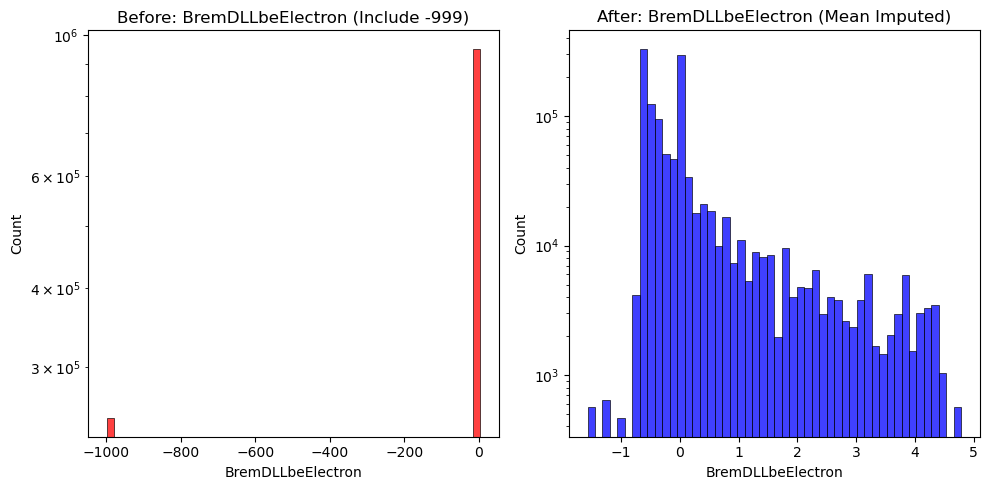

검증 결과: 'BremDLLbeElectron' 컬럼에 남은 -999 개수 = 0 (0이어야 함)
Flag 컬럼 'BremDLLbeElectron_flag' 생성 확인:
 BremDLLbeElectron_flag
0    950439
1    249561
Name: count, dtype: int64


In [113]:
# 검증을 위해 결측치가 있었던 대표적인 컬럼 하나를 선택하여 분포 비교
# 예: 리스트의 첫 번째 컬럼 사용
if len(imputed_cols) > 0:
    target_col = imputed_cols[0]
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # 1. 원본 데이터 분포 (-999 포함)
    sns.histplot(df[target_col], bins=50, ax=axes[0], color='red')
    axes[0].set_title(f'Before: {target_col} (Include -999)')
    axes[0].set_yscale('log') # 빈도 차이가 클 수 있으므로 로그 스케일 적용
    
    # 2. 처리 후 데이터 분포 (Flagging + Mean Imputation)
    sns.histplot(df_imputed[target_col], bins=50, ax=axes[1], color='blue')
    axes[1].set_title(f'After: {target_col} (Mean Imputed)')
    axes[1].set_yscale('log')
    
    plt.tight_layout()
    plt.show()
    
    # 수치적 검증: -999가 남아있는지 확인
    remaining_missing = (df_imputed[target_col] == -999.0).sum()
    print(f"검증 결과: '{target_col}' 컬럼에 남은 -999 개수 = {remaining_missing} (0이어야 함)")
    
    # Flag 컬럼 확인
    flag_col = f"{target_col}_flag"
    print(f"Flag 컬럼 '{flag_col}' 생성 확인:\n", df_imputed[flag_col].value_counts())
else:
    print("결측치가 있는 컬럼이 발견되지 않았습니다.")

▶ 시각화 대상 변수: BremDLLbeElectron


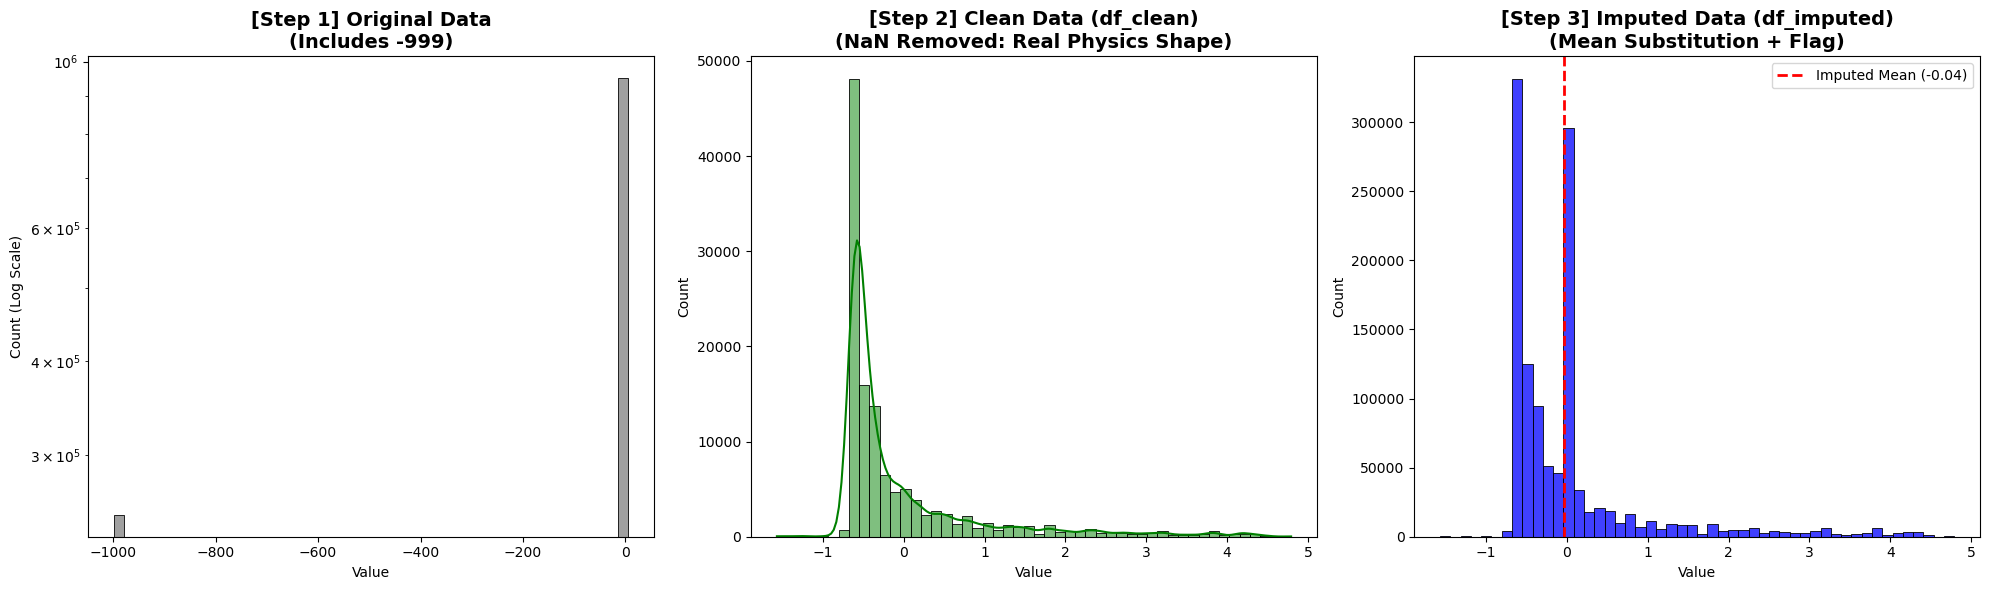

In [114]:
# 3. 3단계 비교 시각화
# 결측치가 존재했던 첫 번째 변수를 자동으로 선택
if len(imputed_cols) > 0:
    target_col = imputed_cols[0] 
    print(f"▶ 시각화 대상 변수: {target_col}")

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # [Plot 1] Original Data (Raw)
    # -999가 포함되어 있어 분포가 왜곡되어 보일 수 있음 -> 로그 스케일 적용
    sns.histplot(df[target_col], bins=50, ax=axes[0], color='gray', kde=False)
    axes[0].set_title(f'[Step 1] Original Data\n(Includes -999)', fontsize=14, fontweight='bold')
    axes[0].set_yscale('log') # 빈도 차이가 크므로 로그 스케일 필수
    axes[0].set_xlabel('Value')
    axes[0].set_ylabel('Count (Log Scale)')

    # [Plot 2] Clean Data (Target Distribution)
    # 우리가 보존하고자 하는 '진짜' 물리적 분포
    valid_data = df_clean[target_col].dropna()
    sns.histplot(valid_data, bins=50, ax=axes[1], color='green', kde=True)
    axes[1].set_title(f'[Step 2] Clean Data (df_clean)\n(NaN Removed: Real Physics Shape)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Value')
    axes[1].set_ylabel('Count')

    # [Plot 3] Imputed Data (Model Input)
    # 평균 대체로 인해 중앙에 값이 몰리는 현상(Spike) 확인
    sns.histplot(df_final[target_col], bins=50, ax=axes[2], color='blue', kde=False)
    
    # 평균값 위치 표시
    mean_val = valid_data.mean()
    axes[2].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Imputed Mean ({mean_val:.2f})')
    
    axes[2].set_title(f'[Step 3] Imputed Data (df_imputed)\n(Mean Substitution + Flag)', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Value')
    axes[2].set_ylabel('Count')
    axes[2].legend()

    plt.tight_layout()
    plt.show()
else:
    print("결측치(-999)를 포함한 변수가 없습니다.")

Imputation 시, 평균에 데이터가 몰리지만, 

MLP가 데이터학습시, flag로 가짜데이터임을 구분할 수 있기 때문에 괜찮음

In [ ]:
from sklearn.preprocessing import StandardScaler

# [Step 2] 데이터 정규화 (Standard Scaling)

# 스케일링 대상 컬럼 식별:
# 1. 수치형 데이터여야 함
# 2. 'Label'이 아니어야 함
# 3. 'Flag'나 '_flag'로 끝나는 이진 변수가 아니어야 함 (선택 사항이나, 물리적 명확성을 위해 제외 추천)
scale_cols = [c for c in df_final.columns 
              if c != 'Label' 
              and not c.startswith('Flag') 
              and not c.endswith('_flag')]

print(f"스케일링 대상 컬럼 수: {len(scale_cols)}")

# 스케일러 객체 생성 및 학습
scaler = StandardScaler()
df_final[scale_cols] = scaler.fit_transform(df_final[scale_cols])

# 검증: 스케일링 된 컬럼 중 하나를 골라 평균 0, 표준편차 1 확인
check_col = scale_cols[0]
mean_val = df_final[check_col].mean()
std_val = df_final[check_col].std()

print(f"\n[검증] 컬럼 '{check_col}' 통계량:")
print(f"  - Mean (should be close to 0): {mean_val:.4f}")
print(f"  - Std  (should be close to 1): {std_val:.4f}")

# 최종 데이터 확인
df_final.head()

스케일링 대상 컬럼 수: 41

[검증] 컬럼 'TrackP' 통계량:
  - Mean (should be close to 0): 0.0000
  - Std  (should be close to 1): 1.0000


,TrackP,TrackNDoFSubdetector2,BremDLLbeElectron,MuonLooseFlag,FlagSpd,SpdE,EcalDLLbeElectron,DLLmuon,RICHpFlagElectron,EcalDLLbeMuon,...,Calo3dFitQuality_flag,MuonLLbeMuon_flag,RICH_DLLbeBCK_flag,HcalDLLbeMuon_flag,RICH_DLLbeKaon_flag,RICH_DLLbeElectron_flag,HcalE_flag,PrsE_flag,RICH_DLLbeMuon_flag,RICH_DLLbeProton_flag
0,2.101859,0.061490,0.212457,2.059124,1.0,0.484849,-0.861966,1.522074e+00,0.226002,1.826636,...,1,0,0,0,0,0,0,0,0,0
1,-0.480336,0.061490,-0.424168,-0.485643,1.0,0.484849,1.307372,3.368220e-01,0.226002,-0.676521,...,0,1,0,0,0,0,0,0,0,0
2,-0.501017,0.556776,0.000000,-0.485643,0.0,0.000000,0.000000,4.150758e-17,-4.424731,0.000000,...,1,1,1,1,1,1,1,1,1,1
3,-0.030960,1.299705,-0.727618,-0.485643,1.0,0.484849,-0.875964,-1.343449e+00,0.226002,-1.423986,...,0,1,0,0,0,0,0,0,0,0
4,-0.307412,1.052062,-0.727594,-0.485643,1.0,0.484849,-0.654183,-1.032293e+00,0.226002,-0.007990,...,0,1,0,0,0,0,0,0,0,0


In [115]:
from sklearn.preprocessing import StandardScaler

# [Step 2] 데이터 정규화 (Standard Scaling)

# 스케일링 대상 컬럼 식별:
# 1. 수치형 데이터여야 함
# 2. 'Label'이 아니어야 함
# 3. 'Flag'나 '_flag'로 끝나는 이진 변수가 아니어야 함 (선택 사항이나, 물리적 명확성을 위해 제외 추천)
scale_cols = [c for c in df_clean.columns 
              if c != 'Label' 
              and not c.startswith('Flag') 
              and not c.endswith('_flag')]

print(f"스케일링 대상 컬럼 수: {len(scale_cols)}")

# 스케일러 객체 생성 및 학습
scaler = StandardScaler()
df_clean[scale_cols] = scaler.fit_transform(df_clean[scale_cols])

# 검증: 스케일링 된 컬럼 중 하나를 골라 평균 0, 표준편차 1 확인
check_col = scale_cols[0]
mean_val = df_clean[check_col].mean()
std_val = df_clean[check_col].std()

print(f"\n[검증] 컬럼 '{check_col}' 통계량:")
print(f"  - Mean (should be close to 0): {mean_val:.4f}")
print(f"  - Std  (should be close to 1): {std_val:.4f}")

# 최종 데이터 확인
df_clean.head()

스케일링 대상 컬럼 수: 41

[검증] 컬럼 'TrackP' 통계량:
  - Mean (should be close to 0): 0.0000
  - Std  (should be close to 1): 1.0000


/var/folders/1f/xp49wx494s78pwbz7rqgscp80000gn/T/ipykernel_14196/2677486798.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[scale_cols] = scaler.fit_transform(df_clean[scale_cols])


,TrackP,TrackNDoFSubdetector2,BremDLLbeElectron,MuonLooseFlag,FlagSpd,SpdE,EcalDLLbeElectron,DLLmuon,RICHpFlagElectron,EcalDLLbeMuon,...,TrackNDoF,RICHpFlagMuon,RICH_DLLbeKaon,RICH_DLLbeElectron,HcalE,MuonFlag,FlagMuon,PrsE,RICH_DLLbeMuon,RICH_DLLbeProton
15,4.242510,-0.462131,0.052963,0.225923,1.0,0.432609,-0.179983,0.149119,0.145578,-0.131456,...,0.830638,0.164943,0.569880,0.273622,0.091285,0.483432,0.0,-0.310649,-0.161502,0.039631
36,4.401853,0.172940,-0.394545,0.225923,1.0,0.432609,-0.547642,0.598194,0.145578,0.779368,...,-0.521556,0.164943,0.432642,0.228831,-0.425668,0.483432,1.0,-0.292987,-0.230700,-0.068163
55,0.690441,0.808010,-0.208628,0.225923,0.0,0.432609,-0.656121,0.268056,0.145578,0.230628,...,0.154541,0.164943,0.647726,0.268701,-0.127275,0.483432,1.0,0.113219,-0.199528,0.517899
57,-0.102592,-0.462131,-0.010225,0.225923,1.0,0.432609,0.209794,-1.145626,0.145578,-1.717083,...,-0.296190,0.164943,1.268218,0.062979,-0.386165,-2.068543,1.0,-0.222343,-0.360525,2.068337
64,-0.441845,-0.462131,0.316908,0.225923,1.0,-2.311557,-0.093490,-1.166085,0.145578,0.225532,...,-0.746922,0.164943,-0.453367,-1.580994,-0.208556,0.483432,1.0,-0.275327,-1.050205,-0.584598


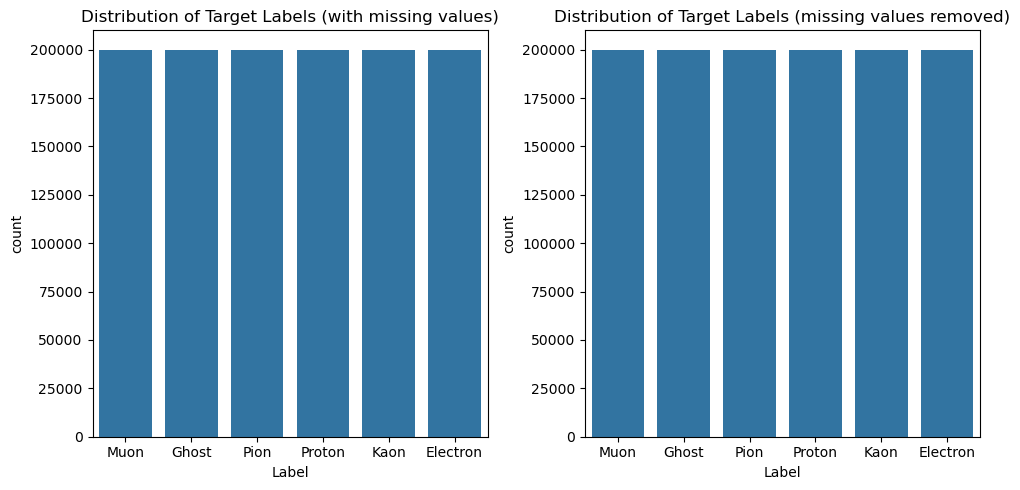

원본 데이터프레임 라벨 분포 비율:
Label
Muon        0.166667
Ghost       0.166667
Pion        0.166667
Proton      0.166667
Kaon        0.166667
Electron    0.166667
Name: proportion, dtype: float64

결측치 제거 후 데이터프레임 라벨 분포 비율:
Label
Muon        0.166667
Ghost       0.166667
Pion        0.166667
Proton      0.166667
Kaon        0.166667
Electron    0.166667
Name: proportion, dtype: float64


In [89]:
# 라벨 분포 시각화 (결측치 포함 vs 결측치 제거 후)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='Label', data=df_final)
plt.title('Distribution of Target Labels (with missing values)')
plt.subplot(1, 2, 2)
sns.countplot(x='Label', data=df_clean, order=df_clean['Label'].value_counts().index)
plt.title('Distribution of Target Labels (missing values removed)')
plt.tight_layout()
plt.show()
# 수치로 확인
print("원본 데이터프레임 라벨 분포 비율:")
print(df['Label'].value_counts(normalize=True))
print("\n결측치 제거 후 데이터프레임 라벨 분포 비율:")
print(df_clean['Label'].value_counts(normalize=True))

## Feature Engineering

# Model

## data split into train and validation sets

In [116]:
import pandas as pd
from sklearn.model_selection import train_test_split

# [Step 1] One-Hot Encoding (타겟 변수)
# 학습 데이터의 정답지 생성
#y_onehot = pd.get_dummies(df_final['Label'], prefix='label')
y_onehot = pd.get_dummies(df_clean['Label'], prefix='label')

# 입력 데이터(X) 설정: 정답(Label) 제거
X = df_clean.drop(['Label'], axis=1)

print("--- Encoding 완료 ---")
print(f"전체 학습 데이터 수: {len(X)}")

# [Step 2] Train / Validation Split
# stratify=y_onehot: 희귀 입자(클래스) 비율을 Train과 Validation에 동일하게 유지
# test_size=0.2: 전체의 20%를 검증용(Validation)으로 떼어냄
X_train, X_val, y_train, y_val = train_test_split(
    X, y_onehot, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_onehot
)

# [Step 3] 데이터 타입 변환 (Deep Learning용 float32)
# GPU 메모리 효율성을 위해 float32 권장
X_train = X_train.astype('float32')
X_val = X_val.astype('float32')
y_train = y_train.astype('float32')
y_val = y_val.astype('float32')

print("\n--- Train/Validation Split 완료 ---")
print(f"Training Set   : {X_train.shape}  (가중치 업데이트용)")
print(f"Validation Set : {X_val.shape}  (성능 평가 및 Early Stopping용)")

# 참고: Test Data는 나중에 별도의 파일(test.csv)을 로드하여
# 위에서 학습한 'scaler'로 똑같이 전처리한 후 평가에 사용합니다.

--- Encoding 완료 ---
전체 학습 데이터 수: 125426

--- Train/Validation Split 완료 ---
Training Set   : (100340, 49)  (가중치 업데이트용)
Validation Set : (25086, 49)  (성능 평가 및 Early Stopping용)


## 데이터 텐서 변환

In [117]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

# 1. Pandas/Numpy -> PyTorch Tensor 변환
# values 속성을 사용하여 numpy 배열로 추출 후 텐서로 변환
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)

# y(Label) 처리: One-Hot Vector -> Class Index (0~5)
# CrossEntropyLoss 사용을 위해 argmax로 인덱스 추출
y_train_indices = torch.tensor(y_train.values, dtype=torch.float32).argmax(dim=1)
y_val_indices = torch.tensor(y_val.values, dtype=torch.float32).argmax(dim=1)

# 2. Dataset & DataLoader 생성
train_dataset = TensorDataset(X_train_tensor, y_train_indices)
val_dataset = TensorDataset(X_val_tensor, y_val_indices)

# Batch Size 설정 (메모리에 따라 조절, 보통 64, 128, 256 등 2의 제곱수 사용)
BATCH_SIZE = 256

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"데이터 로더 준비 완료 (Batch Size: {BATCH_SIZE})")
print(f"Train Batch 개수: {len(train_loader)}")
print(f"Val Batch 개수: {len(val_loader)}")

# 장치 설정 (GPU/MPS/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"사용 장치: {device}")

데이터 로더 준비 완료 (Batch Size: 256)
Train Batch 개수: 392
Val Batch 개수: 98
사용 장치: mps


In [118]:
class ParticleClassifier(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(ParticleClassifier, self).__init__()
        
        # 3-Layer MLP 구조
        self.layers = nn.Sequential(
            # Input Layer -> Hidden 1
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),        # 학습 안정화 및 가속
            nn.ReLU(),
            nn.Dropout(0.2),            # 과적합 방지
            
            # Hidden 1 -> Hidden 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            # Hidden 2 -> Output Layer
            nn.Linear(64, output_dim)
            # Softmax는 Loss Function에 포함되어 있으므로 생략
        )
        
    def forward(self, x):
        return self.layers(x)

# 모델 인스턴스 생성
input_dim = X_train.shape[1]
output_dim = 6 # 입자 클래스 개수

model = ParticleClassifier(input_dim, output_dim).to(device)
print(model)

ParticleClassifier(
  (layers): Sequential(
    (0): Linear(in_features=49, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=6, bias=True)
  )
)


In [124]:
# Hyperparameters
LEARNING_RATE = 0.001
EPOCHS = 20 # Baseline 확인용으로 20회만 진행

# Loss Function & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 결과 기록용 리스트
train_losses = []
val_losses = []
val_accuracies = []

print("--- 학습 시작 ---")

for epoch in range(EPOCHS):
    model.train() # 학습 모드 전환
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # 1. Forward
        outputs = model(inputs)
        loss = criterion(outputs, labels.long()) # labels는 long type(정수)이어야 함
        
        # 2. Backward & Optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    # Epoch 종료 후 Validation 진행
    model.eval() # 평가 모드 전환 (Dropout, BatchNorm 고정)
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad(): # 기울기 계산 안 함 (메모리 절약)
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels.long())
            val_loss += loss.item()
            
            # 정확도 계산
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    # 통계 출력
    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)
    if epoch % 5 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val Acc: {val_acc:.2f}%")

print("--- 학습 종료 ---")

--- 학습 시작 ---
Epoch [1/20] Train Loss: 0.3292 | Val Loss: 0.3244 | Val Acc: 87.08%
Epoch [6/20] Train Loss: 0.3262 | Val Loss: 0.3249 | Val Acc: 87.02%
Epoch [11/20] Train Loss: 0.3270 | Val Loss: 0.3259 | Val Acc: 86.91%
Epoch [16/20] Train Loss: 0.3254 | Val Loss: 0.3260 | Val Acc: 86.98%
--- 학습 종료 ---


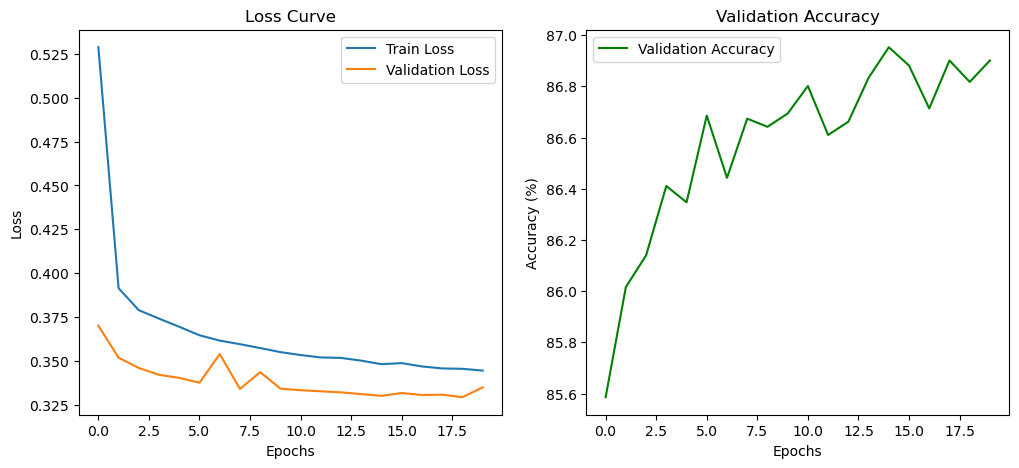

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy', color='green')
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# [1] 좀 더 깊고 복잡한 모델 아키텍처
class DeepParticleClassifier(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DeepParticleClassifier, self).__init__()
        
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            
            nn.Linear(64, output_dim)
        )
        
    def forward(self, x):
        return self.layers(x)

# 모델 인스턴스 생성
input_dim = X_train.shape[1]
output_dim = 6 
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

model = DeepParticleClassifier(input_dim, output_dim).to(device)
print("--- Improved Model Architecture ---")
print(model)

# [2] 고도화된 학습 설정
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# [수정됨] verbose=True 제거
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

criterion = nn.CrossEntropyLoss()

# [3] 학습 루프 (Scheduler 및 LR 출력 포함)
EPOCHS = 30 
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

print("\n--- Start Training with Scheduler ---")

for epoch in range(EPOCHS):
    # 1. Training Mode
    model.train()
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels.long())
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    avg_train_loss = running_loss / len(train_loader)
    
    # 2. Validation Mode
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels.long())
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total
    
    # Scheduler Step
    scheduler.step(avg_val_loss)
    
    # [수정됨] 현재 학습률(Learning Rate)을 직접 가져와서 출력
    current_lr = optimizer.param_groups[0]['lr']
    
    # 기록 저장
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Acc: {val_acc:.2f}% | "
          f"LR: {current_lr:.6f}") # LR 출력 추가

print("--- Training Finished ---")

--- Improved Model Architecture ---
DeepParticleClassifier(
  (layers): Sequential(
    (0): Linear(in_features=49, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.1)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.1)
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=6, bias=True)
  )
)

--- Start Training with Scheduler ---
Epoch [1/30] Train Loss: 0.4934 | Val Loss: 0.3646 | Val Acc: 85.65% | LR: 0.001000
Epoch [2/30] Train Loss: 0.3989 | Val 